# Countywide Structure Exposure Networks

This notebook maps the full spatial extent of the completed Los Angeles County OpenView 3D graph. It focuses on the overview panel of the regional SEN figure and compares two component definitions at the same pooled OpenView destruction-equivalent threshold: cumulative Top-2 first, followed by Every-Edge Above Threshold (EEAT). No fire arrival, ignition, or damage outcomes enter the regional component construction.

In [1]:
import os
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from shapely.geometry import box

cwd = Path.cwd().resolve()
PACKAGE_ROOT = next(
    path for path in [cwd, *cwd.parents]
    if (path / 'data').exists() and (path / 'src').exists()
    and (path / 'notebooks').exists()
)
sys.path.insert(0, str(PACKAGE_ROOT))

from src.analysis.fragility import fit_5pl
from src.analysis.openview_3d_sen import (
    audit_openview_3d_run, build_county_regional_sen,
    load_county_regional_sen_cache, save_county_regional_sen_cache,
)
from src.analysis.regional_sen import (
    regional_category_summary, regional_size_profile,
)
from src.analysis.sen import coupling_at_probability
from src.viz.regional_sen import (
    CMAP, INK, ISOLATED, OTHER, WUI, _draw_buildings, _full_interface,
)
from src.viz.style import apply_style

apply_style()
base_viridis = plt.colormaps['Spectral']
PUBLICATION_CMAP = LinearSegmentedColormap.from_list(
    'spectral_truncated', base_viridis(np.linspace(.05, .88, 256)),
)
SEN_SIZE_BOUNDS = np.array([1, 2, 5, 10, 25, 100, 500, 2049])

SEN_SIZE_COLORS = [
    "#D9D9D6",  # 1: isolated
    "#4575B4",  # 2–4
    "#74ADD1",  # 5–9
    "#ABD9E9",  # 10–24
    "#FEE090",  # 25–99
    "#F46D43",  # 100–499
    "#A50026",  # 500–2,048
]
SEN_SIZE_CMAP = mpl.colors.ListedColormap(
    SEN_SIZE_COLORS, name='sen_size_classes',
)
SEN_SIZE_NORM = mpl.colors.BoundaryNorm(
    SEN_SIZE_BOUNDS, SEN_SIZE_CMAP.N, clip=True,
)
SEN_SIZE_TICKS = (SEN_SIZE_BOUNDS[:-1] + SEN_SIZE_BOUNDS[1:]) / 2
SEN_SIZE_TICKLABELS = [
    '1', '2–4', '5–9', '10–24', '25–99', '100–499', '500–2,048',
]
WUI_PERIMETER_COLOR = '#3B78A3'
OPENVIEW_3D_RUN = Path(os.environ.get(
    'OPENVIEW_3D_BVF_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/lariac6_wui_all_2mi_bvf_3d_nf_cone85_nosolar',
))
RUN_TAG = 'openview3d_lariac6_2mi'
DERIVED = PACKAGE_ROOT / 'data' / 'derived' / RUN_TAG
ANALYSIS_PATH = DERIVED / 'analysis_openview3d.parquet'
BUILDING_CACHE = DERIVED / 'county_buildings.parquet'
TOP2_MAP_CACHE = DERIVED / 'county_sen_top2_map_source.parquet'
TOP2_EDGE_FLOOR_ALPHA = 0.75
EEAT_MAP_CACHE = DERIVED / 'county_sen_eeat_map_source.parquet'
WUI_PATH = PACKAGE_ROOT / 'data' / 'calfire_wui_la.gpkg'
RESULTS = PACKAGE_ROOT / 'results' / RUN_TAG / 's2s_nc'
FIGURES = PACKAGE_ROOT / 'figures' / 's2s_nc/main'
for directory in (DERIVED, RESULTS, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

def regional_cache_matches(map_path, method, threshold, n_neighbors=None, edge_floor_fraction=None):
    component_path = map_path.with_name(
        f'{map_path.stem}_components.parquet'
    )
    summary_path = map_path.with_name(f'{map_path.stem}_summary.parquet')
    if not all(path.exists() for path in (map_path, component_path, summary_path)):
        return False
    try:
        cached = pd.read_parquet(summary_path).iloc[0]
    except (IndexError, OSError, ValueError):
        return False
    try:
        cached_n = cached.get('n_neighbors')
        n_matches = (
            pd.isna(cached_n) if n_neighbors is None
            else int(cached_n) == int(n_neighbors)
        )
        cached_floor = cached.get('edge_floor_fraction')
        floor_matches = (
            pd.isna(cached_floor) if edge_floor_fraction is None
            else np.isclose(float(cached_floor), edge_floor_fraction)
        )
        return (
            cached.get('clustering_method') == method
            and np.isclose(float(cached.get('F_ij_threshold')), threshold)
            and n_matches and floor_matches
        )
    except (TypeError, ValueError):
        return False

COUNTY_PLACES = {
    'Malibu': (-118.779, 34.026),
    'Santa Monica': (-118.490, 34.040),
    'Los Angeles': (-118.244, 34.052),
    'Altadena': (-118.136, 34.190),
    'Pasadena': (-118.145, 34.148),
}
WINDOW_NORTH = 34.2799
WINDOW_SOUTH = 34.0032
WINDOW_WEST = -118.6894
WINDOW_EAST = -118.0096
WINDOW_BOUNDS_LON_LAT = (
    WINDOW_WEST, WINDOW_SOUTH, WINDOW_EAST, WINDOW_NORTH,
)

def plot_county_overview(
    result, title, output_stem, *, bounds_lon_lat=None, show_summary=True,
):
    buildings = result['buildings']
    corridor = result['corridor']
    summary = result['summary'].iloc[0]
    interface = _full_interface(
        PACKAGE_ROOT, buildings.crs, corridor, wui=result['wui'],
    )
    spanning_sizes = buildings.loc[
        buildings.spans_interface_class, 'component_size'
    ]
    maximum = max(2, int(spanning_sizes.max()))
    size_scale_max = int(2 ** np.ceil(np.log2(maximum)))
    norm = LogNorm(vmin=2, vmax=size_scale_max)

    fig = plt.figure(figsize=(11.5, 5.8))
    ax = fig.add_axes([.035, .23, .93, .69])
    if bounds_lon_lat is None:
        xmin, ymin, xmax, ymax = buildings.total_bounds
        xpad = .012 * (xmax - xmin)
        ypad = .04 * (ymax - ymin)
        bounds = (xmin - xpad, xmax + xpad, ymin - ypad, ymax + ypad)
    else:
        projected_window = gpd.GeoSeries(
            [box(*bounds_lon_lat)], crs='EPSG:4326',
        ).to_crs(buildings.crs)
        xmin, ymin, xmax, ymax = projected_window.total_bounds
        bounds = (xmin, xmax, ymin, ymax)
    _draw_buildings(
        ax, buildings, norm, interface, corridor, bounds=bounds,
        labels=True, places_wgs84=COUNTY_PLACES,
    )
    ax.text(0, 1.025, 'a', transform=ax.transAxes, fontsize=9,
            fontweight='bold', va='bottom')
    ax.text(.027, 1.025, title, transform=ax.transAxes, fontsize=8.5,
            fontweight='bold', va='bottom')
    if show_summary:
        ax.text(
            .995, .975,
            f"{int(summary.interface_spanning_SENs):,} Interface-spanning SENs · "
            f"{100 * summary.share_in_interface_spanning_SENs:.1f}% of buildings\n"
            f"largest observed: {int(summary.largest_interface_spanning_SEN):,} "
            'buildings (screen-edge censored)',
            transform=ax.transAxes, ha='right', va='top', fontsize=5.7,
            linespacing=1.12, color=INK, clip_on=False,
        )
    ax.legend(handles=[
        Patch(facecolor=OTHER, edgecolor='none', label='other connected SEN'),
        Patch(facecolor=ISOLATED, edgecolor='none', label='isolated building'),
        Line2D([0], [0], color=WUI, lw=1.1, label='WUI Interface boundary'),
        Line2D([0], [0], color='#8B8B88', lw=.6, ls=(0, (2, 2)),
               label='combined WUI + 2-mile screen'),
    ], loc='upper left', bbox_to_anchor=(.002, .94), fontsize=5.8,
       labelspacing=.35, handlelength=1.4, frameon=True,
       facecolor='white', edgecolor='none', framealpha=.82)

    cbar_ax = fig.add_axes([.22, .09, .56, .024])
    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=CMAP), cax=cbar_ax,
        orientation='horizontal',
    )
    ticks = 2 ** np.arange(1, int(np.log2(size_scale_max)) + 1, 2)
    if ticks[-1] != size_scale_max:
        ticks = np.append(ticks, size_scale_max)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f'{value:,}' for value in ticks])
    cbar.set_label('Buildings in Interface-spanning SEN', fontsize=6.8)
    cbar.ax.tick_params(labelsize=6, length=2)

    stem = FIGURES / output_stem
    fig.savefig(stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
    fig.savefig(stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
                facecolor='white')
    print('saved', stem.with_suffix('.png'))
    return fig

def plot_cluster_centroid_window(
    result, title, output_stem, bounds_lon_lat, *, method_label=None,
):
    buildings = result['buildings']
    mapped_wui = result['wui'].to_crs(buildings.crs)
    window = gpd.GeoSeries(
        [box(*bounds_lon_lat)], crs='EPSG:4326',
    ).to_crs(buildings.crs)
    window_geometry = window.iloc[0]
    xmin, ymin, xmax, ymax = window.total_bounds

    # Use the spatial index through .cx before computing centroids, then
    # impose the exact rule that the building centroid lies in the window.
    candidates = buildings.cx[xmin:xmax, ymin:ymax].copy()
    candidate_points = candidates.geometry.centroid
    inside = candidate_points.intersects(window_geometry)
    subset = candidates.loc[inside].copy()
    points = candidate_points.loc[inside]

    wui_perimeter = gpd.GeoSeries(
        [mapped_wui.geometry.union_all().boundary.intersection(window_geometry)],
        crs=buildings.crs,
    )
    fig, ax = plt.subplots(figsize=(7.2, 3.75))
    ax.scatter(
        points.x, points.y, c=subset.component_size,
        cmap=SEN_SIZE_CMAP, norm=SEN_SIZE_NORM,
        s=.24, linewidths=0, alpha=.90, rasterized=True, zorder=3,
    )
    # A pale under-stroke keeps the mapped-WUI perimeter visible over
    # every component-size color without competing with the data field.
    wui_perimeter.plot(ax=ax, color='white', linewidth=1.8, zorder=5)
    wui_perimeter.plot(
        ax=ax, color=WUI_PERIMETER_COLOR, linewidth=.7, zorder=6,
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(0, 1.025, 'a', transform=ax.transAxes, fontsize=9,
            fontweight='bold', va='bottom')
    ax.text(.035, 1.025, title, transform=ax.transAxes, fontsize=8.5,
            fontweight='bold', va='bottom')
    if method_label:
        ax.text(.995, 1.025, method_label, transform=ax.transAxes,
                ha='right', va='bottom', fontsize=6.2, color='#5F5F5B')
    ax.legend(handles=[
        Line2D([0], [0], color=WUI_PERIMETER_COLOR, lw=1.15,
               label='Mapped WUI perimeter'),
    ], loc='upper left', fontsize=6, frameon=False, handlelength=1.7)

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=SEN_SIZE_NORM, cmap=SEN_SIZE_CMAP), ax=ax,
        orientation='horizontal', fraction=.030, pad=.030, aspect=60,
        boundaries=SEN_SIZE_BOUNDS, ticks=SEN_SIZE_TICKS, spacing='uniform',
    )
    cbar.set_ticklabels(SEN_SIZE_TICKLABELS)
    cbar.set_label('Connected-network size (buildings)', fontsize=6.8)
    cbar.ax.tick_params(labelsize=6, length=2)
    fig.subplots_adjust(left=.025, right=.985, top=.91, bottom=.08)

    stem = FIGURES / output_stem
    fig.savefig(stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
    fig.savefig(stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
                facecolor='white')
    print('saved', stem.with_suffix('.png'))
    return fig, subset


## OpenView graph and common threshold

The regional maps use the same threshold as notebook 04, re-fit from the pooled exposed population in `analysis_openview3d.parquet`. The graph covers the union of all CAL FIRE WUI classes plus a two-mile buffer and retains the OpenView run's 152.4-m candidate radius.

In [2]:
input_audit = audit_openview_3d_run(OPENVIEW_3D_RUN)
analysis = pd.read_parquet(ANALYSIS_PATH)
exposed = analysis.loc[analysis.exposed.eq(1)]
pooled_fit = fit_5pl(exposed.F_destroyed_wmean, exposed.is_destroyed)
F_IJ_THRESHOLD = coupling_at_probability(pooled_fit, .50)
display(input_audit.T.rename(columns={0: 'value'}))
print(f'Common OpenView SEN threshold: F* = {F_IJ_THRESHOLD:.6f}')


,value
model,differential_area_3d
tiles,1815
buildings,1628455
candidate_pairs,20164936
maximum_pair_distance_m,152.4
wui_buffer_m,3218.688
terrain_resolution_m,30
source,/Users/adamswietek/Documents/PostDoc/data/raw_...


Common OpenView SEN threshold: F* = 0.035120


## Full extent — cumulative Top-2

For every building, the two strongest incident pairwise couplings are selected. A building qualifies when it has two distinct neighbors and $F_{i(1)} + F_{i(2)} \geq F^*$. Components use selected links whose endpoints both qualify and whose individual coupling satisfies $F_{ij} \geq 0.75F^*$. The stricter edge floor prevents weak links from piggybacking on a strong companion edge.

In [3]:
if regional_cache_matches(
    TOP2_MAP_CACHE, 'cumulative_top_2', F_IJ_THRESHOLD, n_neighbors=2,
    edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA,
):
    regional_top2 = load_county_regional_sen_cache(
        PACKAGE_ROOT, TOP2_MAP_CACHE, wui_path=WUI_PATH,
    )
    print(f'loaded cached Top-2 assignments: {TOP2_MAP_CACHE}')
else:
    regional_top2 = build_county_regional_sen(
        PACKAGE_ROOT, OPENVIEW_3D_RUN, F_IJ_THRESHOLD, BUILDING_CACHE,
        wui_path=WUI_PATH, n_neighbors=2,
        edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA,
    )
    save_county_regional_sen_cache(regional_top2, TOP2_MAP_CACHE)
    print(f'cached Top-2 assignments: {TOP2_MAP_CACHE}')
top2_summary = regional_top2['summary']
top2_components = regional_top2['components']
top2_size_profile = regional_size_profile(top2_components)
top2_categories = regional_category_summary(regional_top2['buildings'])
top2_summary.to_csv(RESULTS / 'county_sen_top2_summary.csv', index=False)
top2_components.to_csv(RESULTS / 'county_sen_top2_components.csv', index=False)
top2_size_profile.to_csv(
    RESULTS / 'county_sen_top2_size_profile.csv', index=False,
)
top2_categories.to_csv(
    RESULTS / 'county_sen_top2_category_summary.csv', index=False,
)
display(top2_summary.T.rename(columns={0: 'value'}))
display(top2_categories.round(4))


loaded cached Top-2 assignments: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/county_sen_top2_map_source.parquet


,value
corridor,Los Angeles County combined-WUI two-mile screen
clustering_method,cumulative_top_2
n_neighbors,2
edge_floor_fraction,0.75
screen_buffer_m,3218.688
F_ij_threshold,0.03512
P_destroyed_equivalent,0.5
buildings,1628455
candidate_pairs,20164936
active_bonds,1520608


,network_category,buildings,building_share
0,Isolated,141968,0.0872
1,Other connected SEN,1413387,0.8679
2,Interface-spanning SEN,73100,0.0449


## Full extent — Every-Edge Above Threshold (EEAT)

EEAT retains every undirected pairwise edge satisfying $F_{ij} \geq F^*$ and forms connected components of the complete thresholded county graph.

In [4]:
if regional_cache_matches(
    EEAT_MAP_CACHE, 'EEAT', F_IJ_THRESHOLD, n_neighbors=None,
):
    regional_eeat = load_county_regional_sen_cache(
        PACKAGE_ROOT, EEAT_MAP_CACHE, wui_path=WUI_PATH,
    )
    print(f'loaded cached EEAT assignments: {EEAT_MAP_CACHE}')
else:
    regional_eeat = build_county_regional_sen(
        PACKAGE_ROOT, OPENVIEW_3D_RUN, F_IJ_THRESHOLD, BUILDING_CACHE,
        wui_path=WUI_PATH,
    )
    save_county_regional_sen_cache(regional_eeat, EEAT_MAP_CACHE)
    print(f'cached EEAT assignments: {EEAT_MAP_CACHE}')
eeat_summary = regional_eeat['summary']
eeat_components = regional_eeat['components']
eeat_size_profile = regional_size_profile(eeat_components)
eeat_categories = regional_category_summary(regional_eeat['buildings'])
eeat_summary.to_csv(RESULTS / 'county_sen_eeat_summary.csv', index=False)
eeat_components.to_csv(RESULTS / 'county_sen_eeat_components.csv', index=False)
eeat_size_profile.to_csv(
    RESULTS / 'county_sen_eeat_size_profile.csv', index=False,
)
eeat_categories.to_csv(
    RESULTS / 'county_sen_eeat_category_summary.csv', index=False,
)
display(eeat_summary.T.rename(columns={0: 'value'}))
display(eeat_categories.round(4))


loaded cached EEAT assignments: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/county_sen_eeat_map_source.parquet


,value
corridor,Los Angeles County combined-WUI two-mile screen
clustering_method,EEAT
n_neighbors,None
screen_buffer_m,3218.688
F_ij_threshold,0.03512
P_destroyed_equivalent,0.5
buildings,1628455
candidate_pairs,20164936
active_bonds,1495427
SENs,334864


,network_category,buildings,building_share
0,Isolated,183594,0.1127
1,Other connected SEN,1378135,0.8463
2,Interface-spanning SEN,66726,0.0410


## Santa Monica Mountains regional window

The following two cells use the same geographic window for a direct visual comparison of cumulative Top-2 and EEAT components: west $-118.6894$, east $-118.0096$, south $34.0032$, north $34.2799$. The bounds are transformed from WGS84 to the OpenView graph CRS. Every building whose centroid lies inside the window is drawn as a point and colored by its full countywide component size, including singleton and non-Interface-spanning SENs. The window does not cut or rebuild components. The publication composite uses cumulative Top-2 with $\alpha=0.75$ at the P50 fragility threshold; these processing details are kept in the caption text rather than in the artwork.

loaded cached alpha=.75 CTop2 assignments: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/county_sen_top2_alpha075_map_source.parquet
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/fig5_fire_regions_clusters_defense_openview3d_top2.png
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/fig5_fire_regions_clusters_defense_openview3d_ctop2_alpha075.png


,fire,edge_floor_alpha,buildings_in_view,full_graph_SENs_in_view,shared_color_scale_vmin,shared_color_scale_vmax,documented_defense_structures_in_view,documented_defense_structures_firewide
0,PALISADES,0.75,16197,2526,1,204,364,864
1,EATON,0.75,51429,7534,1,204,514,646


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/fig5_santa_monica_mountains_fire_details_openview3d_ctop2_alpha075.png


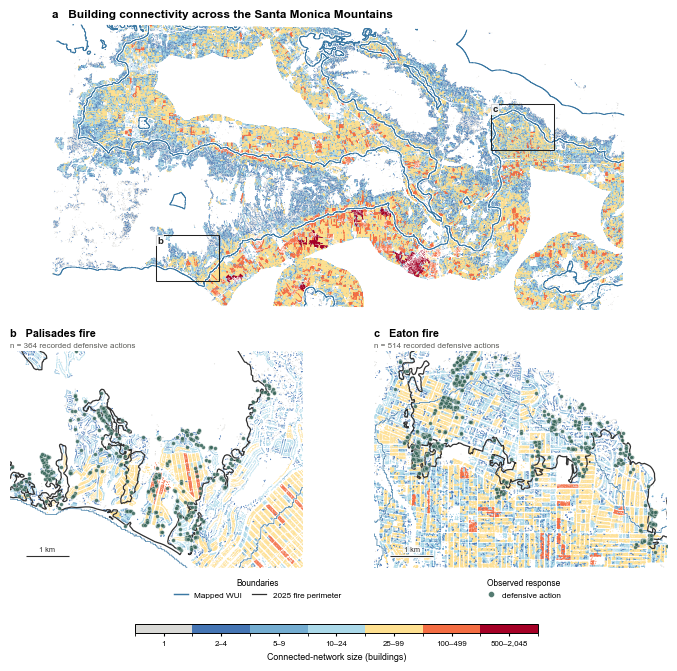

In [7]:
# Fire-region detail: use the full-county CTop2 graph with alpha=.75 and crop only for display.

DEFENSE_COLOR = "#366458FF"
DEFENSE_EDGE = "#FFFFFF"

FIRE_TOP2_ALPHA = 0.75
FIRE_TOP2_MAP_CACHE = DERIVED / 'county_sen_top2_alpha075_map_source.parquet'
if regional_cache_matches(
    FIRE_TOP2_MAP_CACHE, 'cumulative_top_2', F_IJ_THRESHOLD,
    n_neighbors=2, edge_floor_fraction=FIRE_TOP2_ALPHA,
):
    fire_regional_top2 = load_county_regional_sen_cache(
        PACKAGE_ROOT, FIRE_TOP2_MAP_CACHE, wui_path=WUI_PATH,
    )
    print(f'loaded cached alpha=.75 CTop2 assignments: {FIRE_TOP2_MAP_CACHE}')
else:
    fire_regional_top2 = build_county_regional_sen(
        PACKAGE_ROOT, OPENVIEW_3D_RUN, F_IJ_THRESHOLD, BUILDING_CACHE,
        wui_path=WUI_PATH, n_neighbors=2,
        edge_floor_fraction=FIRE_TOP2_ALPHA,
    )
    save_county_regional_sen_cache(fire_regional_top2, FIRE_TOP2_MAP_CACHE)
    print(f'cached alpha=.75 CTop2 assignments: {FIRE_TOP2_MAP_CACHE}')

FIRE_VIEWPORTS = {
    'PALISADES': ((355460, 362340), (3766200, 3771300)),
    'EATON': ((392360, 399240), (3780650, 3785750)),
}
FIRE_CMAPS = {
    'EATON': PUBLICATION_CMAP, 'PALISADES': PUBLICATION_CMAP,
}
# DEFENSE_COLOR = '#D81B60'
dins = pd.read_parquet(
    PACKAGE_ROOT / 'data' / 'enrichment' / 'dins.parquet',
    columns=['BLD_ID', 'is_defended'],
)
defended_ids = set(
    dins.loc[dins.is_defended.eq(True), 'BLD_ID'].astype(str)
)
fire_perimeters = gpd.read_parquet(
    PACKAGE_ROOT / 'data' / 'nx' / 'fire_perims.parquet'
)

buildings = fire_regional_top2['buildings']
fire_views = {}
for fire, (xlim, ylim) in FIRE_VIEWPORTS.items():
    xmin, xmax = xlim
    ymin, ymax = ylim
    candidates = buildings.cx[xmin:xmax, ymin:ymax].copy()
    points = candidates.geometry.centroid
    inside = (
        points.x.between(xmin, xmax) & points.y.between(ymin, ymax)
    )
    fire_views[fire] = (candidates.loc[inside].copy(), points.loc[inside])
shared_scale_min = max(
    1, min(int(subset.component_size.min()) for subset, _ in fire_views.values())
)
shared_scale_max = max(
    shared_scale_min + 1,
    max(int(subset.component_size.max()) for subset, _ in fire_views.values()),
)
shared_norm = LogNorm(vmin=shared_scale_min, vmax=shared_scale_max)
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8))
fire_region_summary = []

for panel, (ax, (fire, (xlim, ylim))) in enumerate(
    zip(axes, FIRE_VIEWPORTS.items())
):
    xmin, xmax = xlim
    ymin, ymax = ylim
    subset, points = fire_views[fire]
    ax.scatter(
        points.x, points.y, c=subset.component_size,
        cmap=FIRE_CMAPS[fire], norm=shared_norm,
        s=.75, linewidths=0, alpha=.90, rasterized=True, zorder=2,
    )

    fire_buildings = gpd.read_parquet(
        PACKAGE_ROOT / 'data' / 'nx' / f'{fire}_buildings.parquet',
        columns=['BLD_ID', 'geometry'],
    ).to_crs(buildings.crs)
    fire_buildings['BLD_ID'] = fire_buildings.BLD_ID.astype(str)
    defended = fire_buildings.loc[
        fire_buildings.BLD_ID.isin(defended_ids)
    ].drop_duplicates('BLD_ID')
    defended_points = defended.geometry.representative_point()
    visible_defense = defended_points.loc[
        defended_points.x.between(xmin, xmax)
        & defended_points.y.between(ymin, ymax)
    ]
    ax.scatter(
        visible_defense.x, visible_defense.y, s=7.5, marker='o',
        facecolors=DEFENSE_COLOR, edgecolors='white', linewidths=.25,
        alpha=.85,
        rasterized=True, zorder=6,
    )

    perimeter = fire_perimeters.loc[
        fire_perimeters.FIRE_NAME.eq(fire)
    ].to_crs(buildings.crs)
    perimeter.boundary.plot(
        ax=ax, color='#303030', linewidth=.9, zorder=7,
    )
    ax.set(xlim=xlim, ylim=ylim)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(
        f'{chr(97 + panel)}  {fire.title()} — CTop2 SENs (α=.75)\n'
        f'{len(subset):,} buildings · {subset.component_id.nunique():,} '
        f'full-graph SENs · {len(visible_defense):,} defended structures',
        loc='left', fontsize=8.1, fontweight='bold', pad=4,
    )
    fire_region_summary.append({
        'fire': fire,
        'edge_floor_alpha': FIRE_TOP2_ALPHA,
        'buildings_in_view': len(subset),
        'full_graph_SENs_in_view': subset.component_id.nunique(),
        'shared_color_scale_vmin': shared_scale_min,
        'shared_color_scale_vmax': shared_scale_max,
        'documented_defense_structures_in_view': len(visible_defense),
        'documented_defense_structures_firewide': len(defended),
    })

fig.legend(handles=[
    Line2D([], [], marker='o', ls='', markerfacecolor='none',
           markeredgecolor=DEFENSE_COLOR, markeredgewidth=.9, markersize=5,
           label='documented defensive action'),
    Line2D([], [], color=INK, lw=.85, label='2025 fire perimeter'),
], loc='lower center', bbox_to_anchor=(.5, .105), ncol=2,
   frameon=False, fontsize=6.5)
tick_exp = np.arange(
    int(np.ceil(np.log2(shared_scale_min))),
    int(np.floor(np.log2(shared_scale_max))) + 1, 2,
)
ticks = sorted(set([shared_scale_min, *(2 ** tick_exp), shared_scale_max]))
cbar_ax = fig.add_axes([.22, .055, .56, .018])
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=shared_norm, cmap=FIRE_CMAPS['EATON']),
    cax=cbar_ax, orientation='horizontal',
)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f'{value:,}' for value in ticks])
cbar.set_label(
    'Buildings in full-county CTop2 SEN (α=.75; displayed panels only)',
    fontsize=6.5,
)
cbar.ax.tick_params(labelsize=5.8, length=2)
fig.subplots_adjust(left=.015, right=.985, top=.91, bottom=.17, wspace=.035)

fire_region_summary = pd.DataFrame(fire_region_summary)
for summary_name in (
    'fire_region_top2_defense_summary.csv',
    'fire_region_ctop2_alpha075_defense_summary.csv',
):
    fire_region_summary.to_csv(RESULTS / summary_name, index=False)
stems = [
    FIGURES / 'fig5_fire_regions_clusters_defense_openview3d_top2',
    FIGURES / 'fig5_fire_regions_clusters_defense_openview3d_ctop2_alpha075',
]
for stem in stems:
    fig.savefig(
        stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white',
    )
    fig.savefig(
        stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
        facecolor='white',
    )
    print('saved', stem.with_suffix('.png'))
plt.close(fig)
display(fire_region_summary)

# Publication figure: regional context above matched fire-detail panels.
overview_window = gpd.GeoSeries(
    [box(*WINDOW_BOUNDS_LON_LAT)], crs='EPSG:4326',
).to_crs(buildings.crs)
overview_geometry = overview_window.iloc[0]
oxmin, oymin, oxmax, oymax = overview_window.total_bounds
# Rebuild the overview subset here so this publication figure does not
# depend on a separate exploratory plotting cell having been executed.
overview_candidates = buildings.cx[oxmin:oxmax, oymin:oymax].copy()
overview_candidate_points = overview_candidates.geometry.centroid
inside_overview = overview_candidate_points.intersects(overview_geometry)
mountains_top2 = overview_candidates.loc[inside_overview].copy()
overview_points = overview_candidate_points.loc[inside_overview]
mapped_wui = fire_regional_top2['wui'].to_crs(buildings.crs)
full_mapped_wui_boundary = mapped_wui.geometry.union_all().boundary
mapped_wui_perimeter = gpd.GeoSeries(
    [full_mapped_wui_boundary.intersection(overview_geometry)],
    crs=buildings.crs,
)
publication_norm = SEN_SIZE_NORM
publication_cmap = SEN_SIZE_CMAP

fig_publication = plt.figure(figsize=(7.2, 6.55))
grid = fig_publication.add_gridspec(
    2, 2, height_ratios=(1.08, .82), hspace=.16, wspace=.09,
)
overview_ax = fig_publication.add_subplot(grid[0, :])
overview_ax.scatter(
    overview_points.x, overview_points.y,
    c=mountains_top2.component_size, cmap=publication_cmap,
    norm=publication_norm,
    s=.20, linewidths=0, alpha=.90, rasterized=True, zorder=2,
)
mapped_wui_perimeter.plot(
    ax=overview_ax, color='white', linewidth=1.8, zorder=5,
)
mapped_wui_perimeter.plot(
    ax=overview_ax, color=WUI_PERIMETER_COLOR, linewidth=.7, zorder=6,
)
for locator_label, (fire, (xlim, ylim)) in zip(
    ('b', 'c'), FIRE_VIEWPORTS.items(),
):
    xmin, xmax = xlim
    ymin, ymax = ylim
    overview_ax.add_patch(Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin, fill=False,
        edgecolor='#202020', linewidth=.75, zorder=8,
    ))
    overview_ax.text(
        xmin + 110, ymax - 110, locator_label, ha='left', va='top',
        fontsize=7, fontweight='bold', color='#202020', zorder=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=.82, pad=.8),
    )
overview_ax.set(xlim=(oxmin, oxmax), ylim=(oymin, oymax))
overview_ax.set_aspect('equal')
overview_ax.set_xticks([]); overview_ax.set_yticks([])
for spine in overview_ax.spines.values():
    spine.set_visible(False)
overview_ax.set_title(
    'a   Building connectivity across the Santa Monica Mountains',
    loc='left',
    fontsize=8.5, fontweight='bold', pad=5,
)

detail_axes = [
    fig_publication.add_subplot(grid[1, 0]),
    fig_publication.add_subplot(grid[1, 1]),
]
for panel_label, ax, (fire, (xlim, ylim)) in zip(
    ('b', 'c'), detail_axes, FIRE_VIEWPORTS.items(),
):
    xmin, xmax = xlim
    ymin, ymax = ylim
    subset, points = fire_views[fire]
    ax.scatter(
        points.x, points.y, c=subset.component_size,
        cmap=publication_cmap,
        norm=publication_norm, s=.62, linewidths=0, alpha=.91,
        rasterized=True, zorder=2,
    )
    fire_buildings = gpd.read_parquet(
        PACKAGE_ROOT / 'data' / 'nx' / f'{fire}_buildings.parquet',
        columns=['BLD_ID', 'geometry'],
    ).to_crs(buildings.crs)
    fire_buildings['BLD_ID'] = fire_buildings.BLD_ID.astype(str)
    defended = fire_buildings.loc[
        fire_buildings.BLD_ID.isin(defended_ids)
    ].drop_duplicates('BLD_ID')
    defended_points = defended.geometry.representative_point()
    visible_defense = defended_points.loc[
        defended_points.x.between(xmin, xmax)
        & defended_points.y.between(ymin, ymax)
    ]
    detail_wui = gpd.GeoSeries(
        [full_mapped_wui_boundary.intersection(
            box(xmin, ymin, xmax, ymax)
        )], crs=buildings.crs,
    )
    detail_wui.plot(ax=ax, color='white', linewidth=1.25, zorder=3)
    detail_wui.plot(
        ax=ax, color=WUI_PERIMETER_COLOR, linewidth=.5, zorder=4,
    )
    perimeter = fire_perimeters.loc[
        fire_perimeters.FIRE_NAME.eq(fire)
    ].to_crs(buildings.crs)
    perimeter.boundary.plot(
        ax=ax, color='#303030', linewidth=.9, zorder=5,
    )
    ax.scatter(
        visible_defense.x, visible_defense.y, s=7.5, marker='o',
        facecolors=DEFENSE_COLOR, edgecolors='white', linewidths=.25,
        alpha=.85, rasterized=True, zorder=6,
    )
    ax.set(xlim=xlim, ylim=ylim)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(
        0, 1.055, f'{panel_label}   {fire.title()} fire',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=7.8, fontweight='bold',
    )
    ax.text(
        0, 1.012, f'n = {len(visible_defense):,} recorded defensive actions',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=5.8, color='#5F5F5B',
    )
    scale_x = xmin + .055 * (xmax - xmin)
    scale_y = ymin + .055 * (ymax - ymin)
    ax.plot(
        [scale_x, scale_x + 1000], [scale_y, scale_y],
        color='white', linewidth=2.2, solid_capstyle='butt', zorder=8,
    )
    ax.plot(
        [scale_x, scale_x + 1000], [scale_y, scale_y],
        color='#303030', linewidth=.8, solid_capstyle='butt', zorder=9,
    )
    ax.text(
        scale_x + 500, scale_y + .018 * (ymax - ymin), '1 km',
        ha='center', va='bottom', fontsize=5.3, color='#303030',
        zorder=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=.72, pad=.4),
    )



boundary_legend = fig_publication.legend(handles=[
    Line2D([], [], color=WUI_PERIMETER_COLOR, lw=1.05,
           label='Mapped WUI'),
    Line2D([], [], color='#303030', lw=.9, label='2025 fire perimeter'),
], title='Boundaries', loc='lower center', bbox_to_anchor=(.39, .078),
   ncol=2, frameon=False, fontsize=5.9, title_fontsize=6.1,
   columnspacing=1.25, handlelength=1.7)
response_legend = fig_publication.legend(handles=[
    Line2D([], [], marker='o', ls='', markerfacecolor=DEFENSE_COLOR,
           markeredgecolor=DEFENSE_EDGE, markeredgewidth=.25, markersize=4.2,
           alpha=.85, label='defensive action'),
], title='Observed response', loc='lower center',
   bbox_to_anchor=(.76, .078), frameon=False, fontsize=5.9,
   title_fontsize=6.1, handlelength=1.2)
publication_cbar_ax = fig_publication.add_axes([.22, .036, .56, .014])
publication_cbar = fig_publication.colorbar(
    plt.cm.ScalarMappable(
        norm=publication_norm, cmap=publication_cmap,
    ),
    cax=publication_cbar_ax, orientation='horizontal',
    boundaries=SEN_SIZE_BOUNDS, ticks=SEN_SIZE_TICKS, spacing='uniform',
)
publication_cbar.set_ticklabels(SEN_SIZE_TICKLABELS)
publication_cbar.set_label(
    'Connected-network size (buildings)', fontsize=6.4,
)
publication_cbar.ax.tick_params(labelsize=5.7, length=2)
fig_publication.subplots_adjust(
    left=.018, right=.988, top=.965, bottom=.135,
)
publication_stem = (
    FIGURES
    / 'fig5_santa_monica_mountains_fire_details_openview3d_ctop2_alpha075'
)
fig_publication.savefig(
    publication_stem.with_suffix('.pdf'), bbox_inches='tight',
    facecolor='white',
)
fig_publication.savefig(
    publication_stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
    facecolor='white',
)
print('saved', publication_stem.with_suffix('.png'))
plt.show()


## P25, P50, and P75 threshold sensitivity and Interconnectivity persistence

The pooled OpenView 3D fragility curves are inverted at P25, P50, and P75. The cumulative-dose curve supplies thresholds for cumulative Top-2 and EEAT. Cumulative Top-2 retains only selected edges satisfying the more restrictive requirement $F_{ij} \geq 0.75F^*$, which better limits weak connections across major highways. A separate **Fmax curve**, fitted to each exposed building's maximum destroyed-neighbor pair dose, supplies thresholds for **Top-2-pruned EEAT**. In that method, each building contributes at most its two strongest incident edges and the Fmax threshold is applied to each edge individually—the two edge weights are not summed. WUI membership remains a post-clustering label. **Interconnectivity** refers only to buildings outside the mapped WUI whose component also reaches the mapped Interface.

Because thresholded memberships are nested, the map assigns each outside-WUI building the **highest probability-equivalent threshold** at which it remains in an Interface-connected component. Sequential red shades encode P25, P50, and P75 persistence. Buildings inside the Influence, Intermix, or Interface classes are neutral gray, and the three official WUI boundaries are drawn as separate reference lines. The map is cropped only for display to the fixed Santa Monica Mountains window; components are never rebuilt within the crop.


In [ ]:
import importlib
import src.analysis.openview_3d_sen as openview_sen
importlib.reload(openview_sen)

THRESHOLD_PROBABILITIES = np.array([.25, .50, .75])
THRESHOLD_TOP2_EDGE_FLOOR_ALPHA = 0.75
probability_thresholds = pd.DataFrame({
    'probability': THRESHOLD_PROBABILITIES,
    'F_ij_threshold': [
        coupling_at_probability(pooled_fit, probability)
        for probability in THRESHOLD_PROBABILITIES
    ],
})
fmax_exposed = exposed.loc[
    exposed.dose_max_pair.notna() & exposed.dose_max_pair.gt(0)
].copy()
if len(fmax_exposed) != len(exposed):
    raise ValueError('Fmax and cumulative fragility fits must use the same exposed sample')
fmax_fit = fit_5pl(fmax_exposed.dose_max_pair, fmax_exposed.is_destroyed)
fmax_probability_thresholds = pd.DataFrame({
    'probability': THRESHOLD_PROBABILITIES,
    'F_ij_threshold': [
        coupling_at_probability(fmax_fit, probability)
        for probability in THRESHOLD_PROBABILITIES
    ],
})
THRESHOLD_PERSISTENCE_MAP = DERIVED / 'county_sen_p25_p50_p75_santa_monica_persistence_eeat_top2_fmax_alpha075.parquet'
THRESHOLD_SENSITIVITY_SUMMARY = RESULTS / 'county_sen_p25_p50_p75_threshold_sensitivity_eeat_top2_fmax_alpha075.csv'
threshold_persistence_map, threshold_sensitivity = (
    openview_sen.build_county_threshold_persistence(
        OPENVIEW_3D_RUN, EEAT_MAP_CACHE, probability_thresholds,
        fmax_probability_thresholds,
        WINDOW_BOUNDS_LON_LAT, THRESHOLD_PERSISTENCE_MAP,
        THRESHOLD_SENSITIVITY_SUMMARY, n_neighbors=2,
        edge_floor_fraction=THRESHOLD_TOP2_EDGE_FLOOR_ALPHA,
    )
)
display(pd.concat([
    probability_thresholds.assign(calibration='cumulative dose'),
    fmax_probability_thresholds.assign(calibration='Fmax'),
]).sort_values(['probability', 'calibration']).round(6))
display(pd.DataFrame([
    {'calibration': 'cumulative dose', 'n': len(exposed),
     'fragility_midpoint_F50': pooled_fit['f50'],
     'absolute_P50_threshold': coupling_at_probability(pooled_fit, .5)},
    {'calibration': 'Fmax', 'n': len(fmax_exposed),
     'fragility_midpoint_F50': fmax_fit['f50'],
     'absolute_P50_threshold': coupling_at_probability(fmax_fit, .5)},
]).round(6))
display(threshold_sensitivity)


,probability,F_ij_threshold,calibration
0,0.25,0.005201,Fmax
0,0.25,0.013284,cumulative dose
1,0.50,0.012920,Fmax
1,0.50,0.035120,cumulative dose
2,0.75,0.031106,Fmax
2,0.75,0.074140,cumulative dose


,calibration,n,fragility_midpoint_F50,absolute_P50_threshold
0,cumulative dose,24277,0.036502,0.03512
1,Fmax,24277,0.012677,0.01292


,method,probability,F_ij_threshold,edge_floor_fraction,full_county_components,interface_spanning_components,buildings_in_interface_spanning_components,share_in_interface_spanning_components,largest_interface_spanning_component,interface_spanning_buildings_in_window,interface_spanning_components_in_window
0,top2,0.25,0.013284,0.75,109961,2059,196647,0.120757,9174,171830,1572
1,top2,0.50,0.035120,0.75,268512,2581,73100,0.044889,846,63383,2000
2,top2,0.75,0.074140,0.75,584070,2437,26257,0.016124,106,22542,1979
3,eeat,0.25,0.013284,NaN,108538,1613,379966,0.233329,128849,339936,1173
4,eeat,0.50,0.035120,NaN,334864,2491,66726,0.040975,2494,58751,1933
5,eeat,0.75,0.074140,NaN,728106,2183,17018,0.010450,78,14573,1799
6,eeat_top2_fmax,0.25,0.005201,NaN,53801,1539,325607,0.199948,27485,275928,1170
7,eeat_top2_fmax,0.50,0.012920,NaN,123566,2301,147465,0.090555,5274,129184,1762
8,eeat_top2_fmax,0.75,0.031106,NaN,302904,2620,60595,0.037210,657,52268,2038


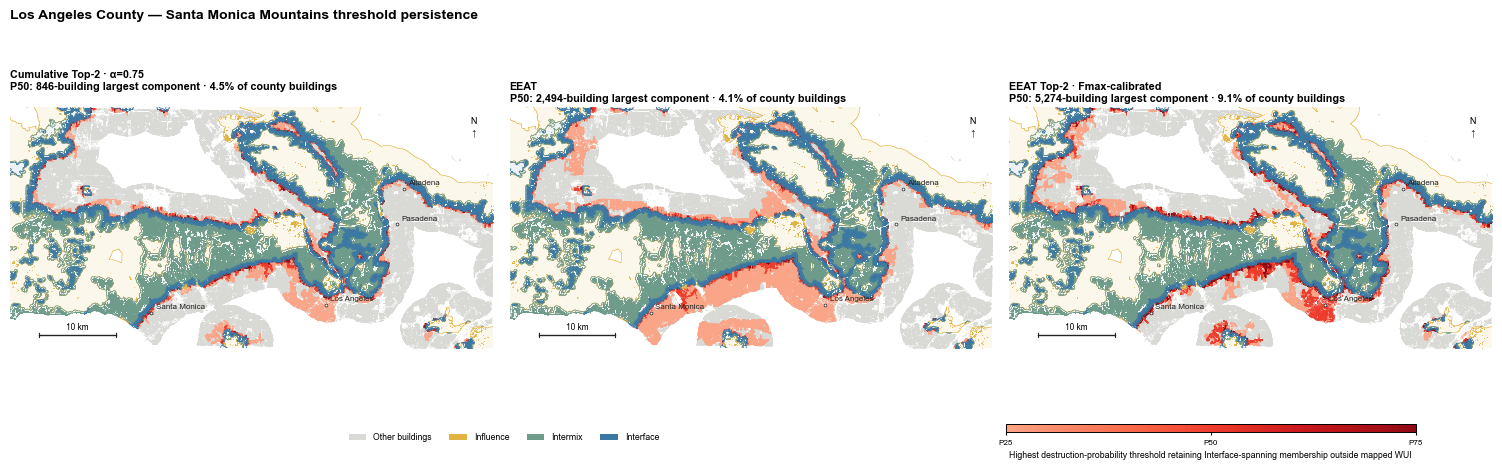

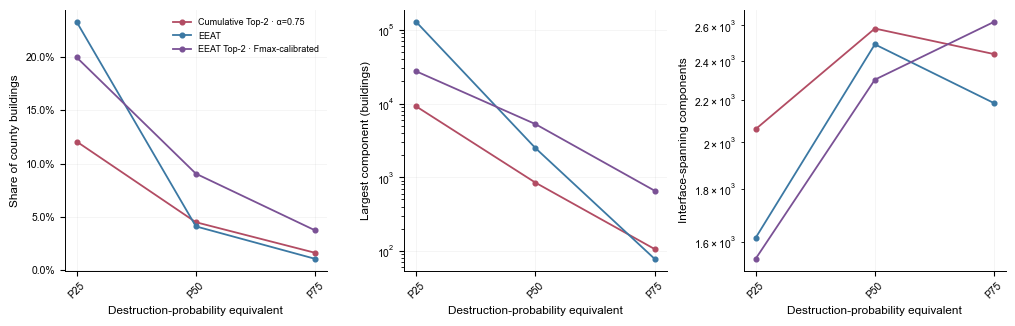

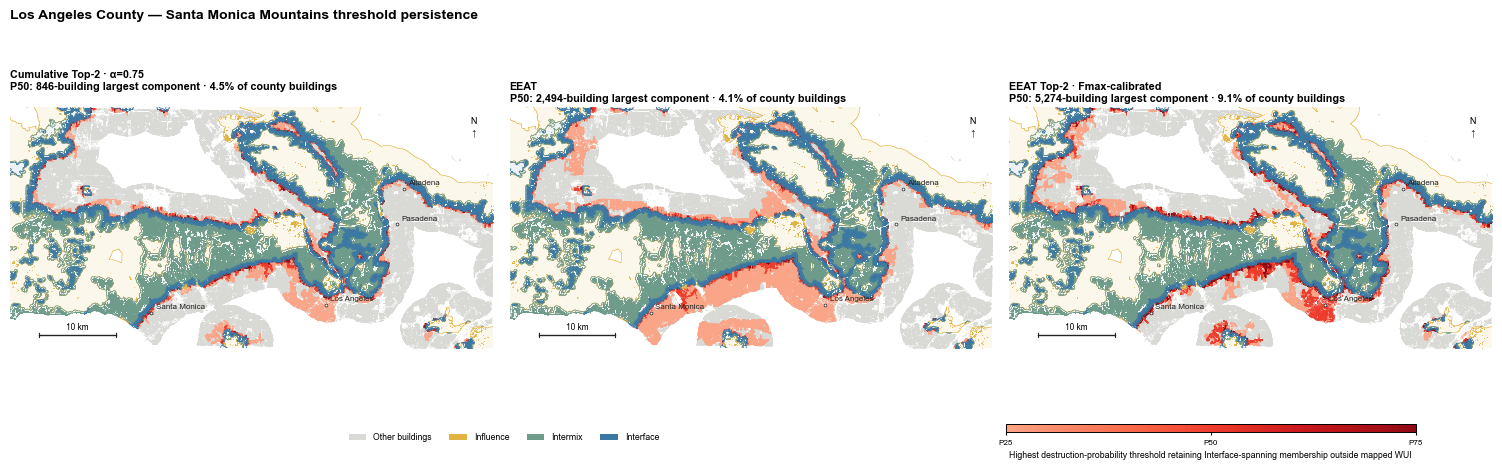

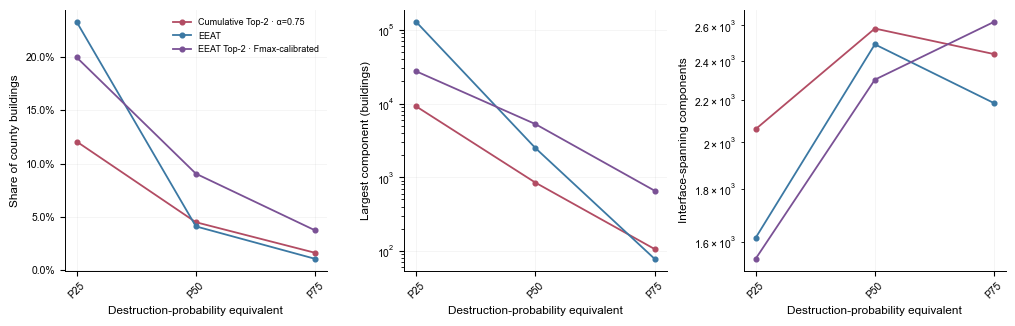

In [ ]:
import src.viz.carsen as carsen_viz
importlib.reload(carsen_viz)

fig_threshold_map = carsen_viz.plot_threshold_persistence_panel(
    threshold_persistence_map, threshold_sensitivity, regional_eeat['wui'],
    FIGURES / 'fig5_santa_monica_p25_p50_p75_threshold_persistence_eeat_top2_fmax_alpha075',
    places=COUNTY_PLACES,
)
fig_threshold_curves = carsen_viz.plot_threshold_sensitivity_curves(
    threshold_sensitivity,
    FIGURES / 'fig5_county_p25_p50_p75_threshold_sensitivity_curves_eeat_top2_fmax_alpha075',
)
display(fig_threshold_map)
fig_threshold_curves


## Connectivity within the existing mapped WUI

This comparison holds the destruction-equivalent threshold at P50 and treats the existing Influence, Intermix, and Interface zones as one combined mapped-WUI population. For cumulative Top-2 with $\alpha=0.75$ and EEAT, mapped-WUI buildings are colored on a shared logarithmic red scale by the number of mapped-WUI buildings contained in their full-county component. The Influence Zone is shown beneath the buildings with a low-opacity sage fill for landscape context only.

,method,buildings_in_view,mapped_wui_buildings_in_view,largest_mapped_wui_component,connected_mapped_wui_buildings_in_view,connected_mapped_wui_share_in_view
0,Cumulative Top-2 · alpha=.75,1048166,337809,394,290905,0.8612
1,EEAT,1048166,337809,1127,276597,0.8188


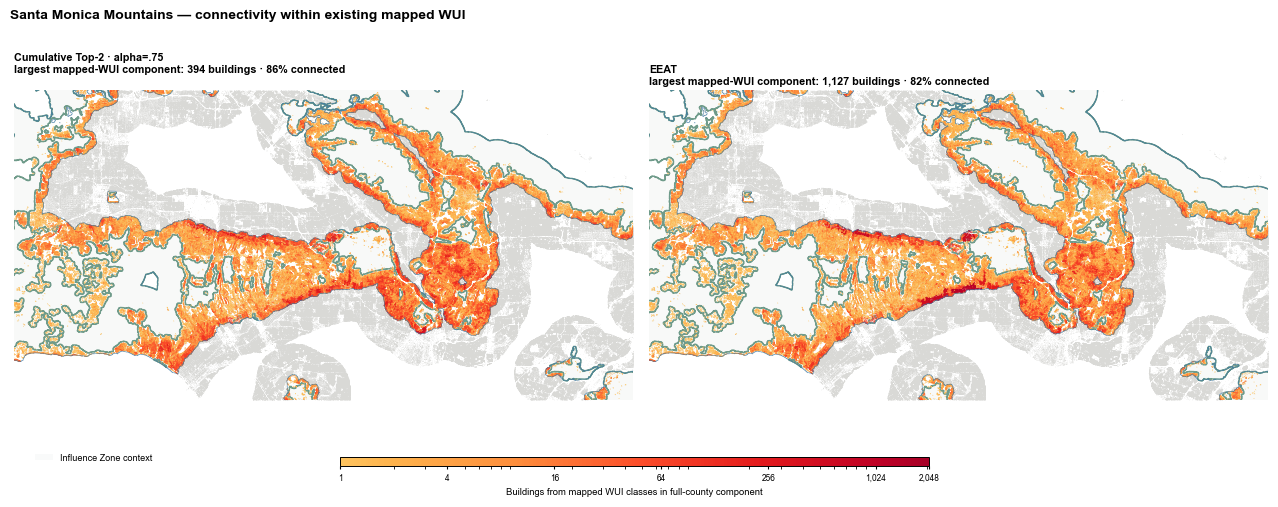

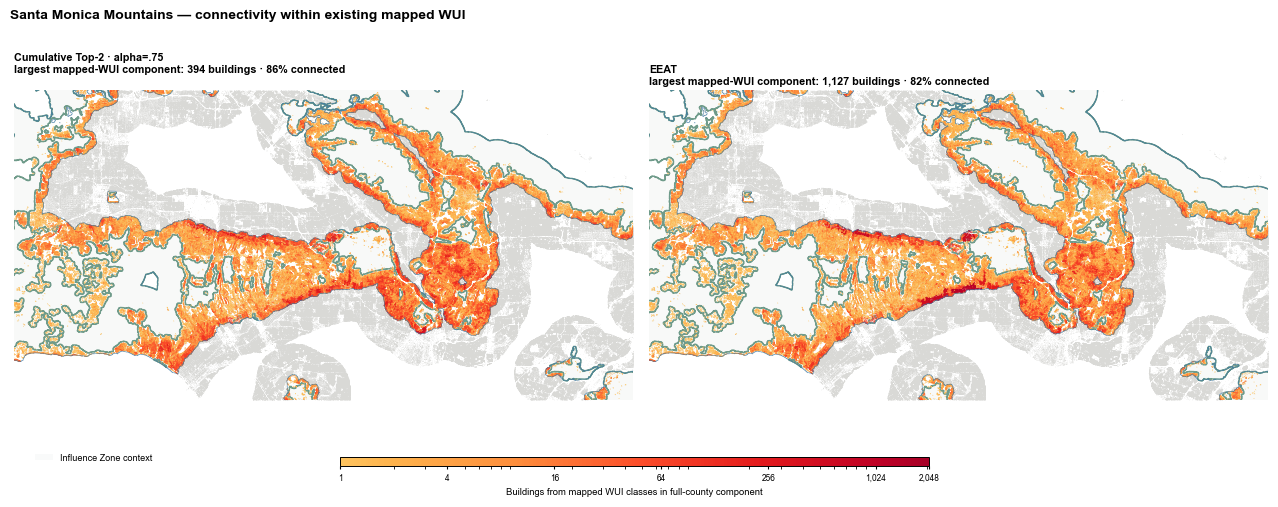

In [ ]:
import importlib
import src.viz.carsen as carsen_viz
importlib.reload(carsen_viz)

wui_window = gpd.GeoSeries(
    [box(*WINDOW_BOUNDS_LON_LAT)], crs='EPSG:4326',
).to_crs(regional_eeat['buildings'].crs)
wui_window_bounds = tuple(wui_window.total_bounds)
fig_wui_connectivity, wui_connectivity_summary = (
    carsen_viz.plot_existing_wui_connectivity(
        {
            'Cumulative Top-2 · alpha=.75': regional_top2['buildings'],
            'EEAT': regional_eeat['buildings'],
        },
        regional_eeat['wui'], wui_window_bounds,
        FIGURES / 'fig5_santa_monica_existing_wui_connectivity_top2_alpha075_vs_eeat_p50',
        cmap ='YlOrRd', INFLUENCE_CMAP="#E8ECE9"
    )
)
wui_connectivity_summary.to_csv(
    RESULTS / 'county_existing_wui_connectivity_top2_alpha075_vs_eeat_p50.csv',
    index=False,
)
display(wui_connectivity_summary.round(4))
fig_wui_connectivity


## EEAT Interconnectivity persistence and outward Interface sensitivity

The map now isolates **Interconnectivity outside the mapped WUI** across the P25, P50, and P75 EEAT thresholds. Structures inside the Influence, Intermix, and Interface classes are shown in neutral gray, while their official boundaries remain distinct yellow, green, and blue reference lines. Outside-WUI structures that do not belong to an Interface-connected component are omitted. The accompanying bar chart retains the earlier fixed-P50 sensitivity to outward Interface expansions of 0.5, 1.0, and 1.5 miles.

,interface_expansion_miles,expanded_interface_area_km2,buildings_inside_expanded_interface,interacting_connected_components,interacting_components_ge_10,interacting_components_ge_25,interacting_components_ge_50,interacting_components_ge_100,la_buildings_in_interacting_components,largest_interacting_global_component,largest_interacting_la_component,newly_interacting_components,largest_new_global_component
0,0.0,232.245975,201210,23022,4780,1787,585,101,207348,2494,2494,23022,2494
1,0.5,884.308886,530444,54896,11471,4169,1352,236,494218,3908,3908,31874,3908
2,1.0,1350.747402,765588,75328,16656,6298,2026,362,705298,3908,3908,20432,2100
3,1.5,1742.988746,1019867,94271,22339,8857,2928,527,933955,3908,3908,18943,689


,method,minimum_component_size,buildings_inside_mapped_wui_in_view,outside_wui_buildings_hidden,interconnectivity_retained_at_p25,interconnectivity_retained_at_p50,interconnectivity_retained_at_p75
0,EEAT,10,336511,494330,203723,23262,4023


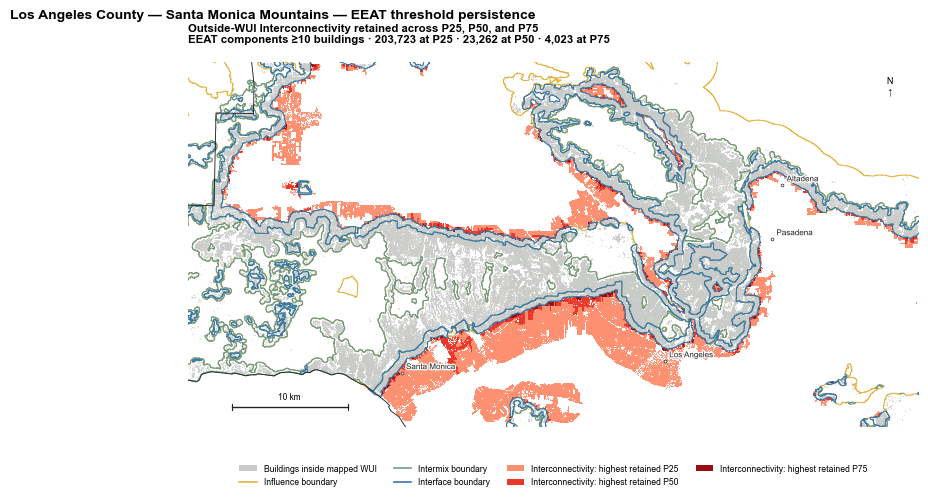

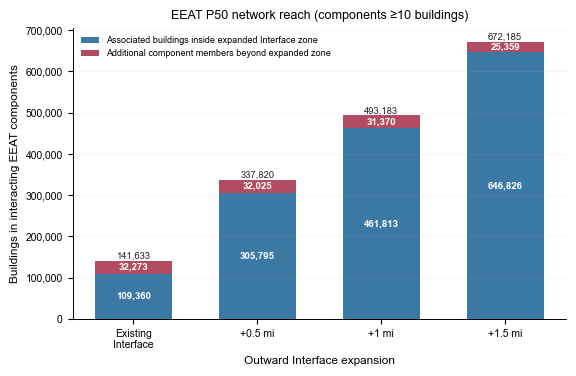

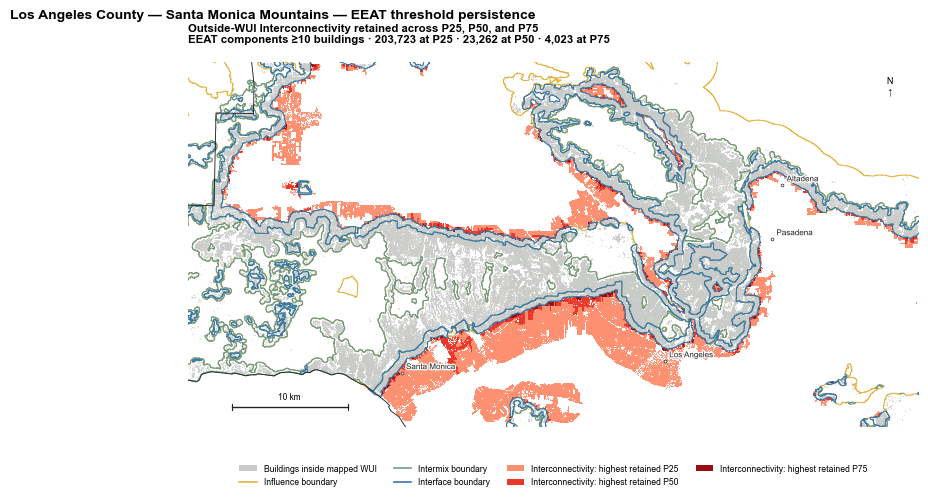

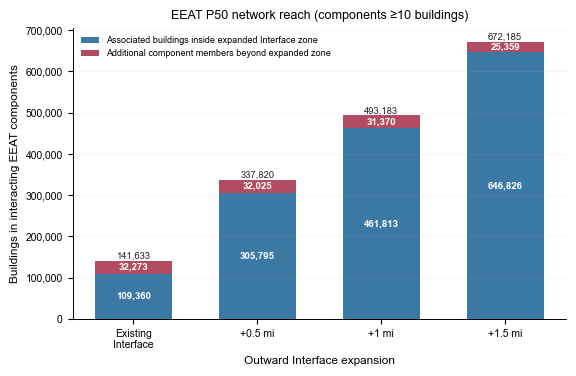

In [ ]:
import importlib
import src.analysis.carsen as carsen_analysis
import src.viz.carsen as carsen_viz
importlib.reload(carsen_analysis)
importlib.reload(carsen_viz)

EEAT_INTERFACE_EXPANSION_MILES = (0.0, 0.5, 1.0, 1.5)
EEAT_CENTROIDS = DERIVED / 'county_sen_eeat_centroids.parquet'
LA_COUNTY_BOUNDARY = (
    PACKAGE_ROOT.parent / 'data' / 'reference'
    / 'la_county_mainland_boundary.parquet'
)
la_county_boundary = gpd.read_parquet(LA_COUNTY_BOUNDARY).to_crs(
    regional_eeat['buildings'].crs
)
eeat_points = regional_eeat['buildings'].geometry.representative_point()
pd.DataFrame({
    'building_id': regional_eeat['buildings'].building_id.to_numpy(),
    'x': eeat_points.x.to_numpy(),
    'y': eeat_points.y.to_numpy(),
}).to_parquet(EEAT_CENTROIDS, index=False)

wui_label_lookup = {
    'Influence': 'Influence Zone',
    'Intermix': 'Intermix',
    'Interface': 'Interface',
}
eeat_wui_classes = {
    name: regional_eeat['wui'].loc[
        regional_eeat['wui'].WUI_DESC.eq(source_name)
    ].copy()
    for name, source_name in wui_label_lookup.items()
}
eeat_interface_sensitivity, eeat_interface_components, eeat_interface_buffers = (
    carsen_analysis.eeat_interface_buffer_sensitivity(
        EEAT_MAP_CACHE, EEAT_CENTROIDS, eeat_wui_classes['Interface'],
        la_county_boundary,
        buffer_miles=EEAT_INTERFACE_EXPANSION_MILES,
    )
)
eeat_interface_sensitivity.to_csv(
    RESULTS / 'county_eeat_p50_interface_expansion_00_15mi.csv', index=False,
)
eeat_interface_components.to_parquet(
    DERIVED / 'county_eeat_p50_interface_expansion_00_15mi_components.parquet',
    index=False,
)
eeat_interface_buffers.to_parquet(
    DERIVED / 'county_eeat_p50_interface_expansion_00_15mi_geometries.parquet',
    index=False,
)

window = gpd.GeoSeries(
    [box(*WINDOW_BOUNDS_LON_LAT)], crs='EPSG:4326',
).to_crs(regional_eeat['buildings'].crs)
eeat_window_bounds = tuple(window.total_bounds)
fig_eeat_interconnectivity, eeat_interconnectivity_summary = (
    carsen_viz.plot_eeat_interconnectivity_persistence_map(
        threshold_persistence_map, regional_eeat['wui'],
        la_county_boundary, eeat_window_bounds,
        FIGURES / 'fig5_santa_monica_eeat_interconnectivity_p25_p50_p75',
        probabilities=tuple(THRESHOLD_PROBABILITIES),
        minimum_component_size=10, places=COUNTY_PLACES,
    )
)
eeat_interconnectivity_summary.to_csv(
    RESULTS / 'county_eeat_interconnectivity_p25_p50_p75_map_summary.csv',
    index=False,
)
fig_eeat_expansion_counts, eeat_expansion_building_counts = (
    carsen_viz.plot_eeat_interface_expansion_building_counts(
        EEAT_MAP_CACHE, eeat_interface_components, EEAT_CENTROIDS,
        la_county_boundary, eeat_interface_buffers,
        FIGURES / 'fig5_county_eeat_p50_interface_expansion_building_counts',
        buffer_miles=EEAT_INTERFACE_EXPANSION_MILES,
        minimum_component_size=10,
    )
)
eeat_expansion_building_counts.to_csv(
    RESULTS / 'county_eeat_p50_interface_expansion_building_counts.csv',
    index=False,
)
display(eeat_interface_sensitivity)
display(eeat_interconnectivity_summary)
display(fig_eeat_interconnectivity)
fig_eeat_expansion_counts


## Paper figure — connectivity within and beyond the mapped WUI

Each figure uses the Santa Monica Mountains window, cropped to the largest rectangle inside the projected window so both panels show the same buildings; components are built countywide and never rebuilt within the crop. **Panel a** colors mapped-WUI buildings (Influence Zone, Intermix, Interface) by the number of mapped-WUI buildings in their full-county SEN at P50. **Panel b** uses the P25, P50, and P75 threshold-persistence sweep: every other structure inside and outside mapped WUI is neutral gray, only outside-WUI **Interconnectivity** is colored red, and thin yellow, green, and blue lines retain the Influence, Intermix, and Interface boundaries. The 2025 Eaton and Palisades fire perimeters are outlined in both panels. Both figures share one panel-a size scale, so the cumulative Top-2 and EEAT versions remain directly comparable.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/fig5_santa_monica_wui_connectivity_persistence_top2_alpha075_p50.png


,0
method,Cumulative Top-2 · α = 0.75 · P50
persistence_method,top2
buildings_in_view,1011018
mapped_wui_buildings_in_view,333457
largest_mapped_wui_component,394
connected_mapped_wui_share_in_view,0.861113
outside_wui_buildings_in_view,677559
minimum_component_size,10
fire_perimeters_shown,2
outside_wui_interface_spanning_at_p25,66080


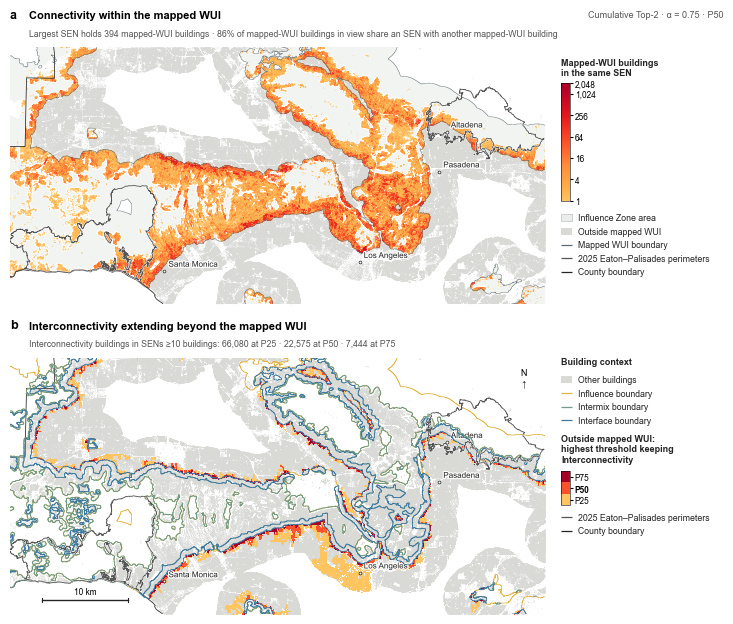

In [ ]:
importlib.reload(carsen_viz)

# Panel b reads the P25/P50/P75 persistence sweep, whose Top-2 edge floor must
# match the P50 graph in panel a.
if not np.isclose(THRESHOLD_TOP2_EDGE_FLOOR_ALPHA, TOP2_EDGE_FLOOR_ALPHA):
    raise ValueError('Persistence sweep and P50 Top-2 graph use different edge floors')
# One size scale for both paper figures, from the P50 comparison above.
WUI_FIGURE_SIZE_SCALE_MAX = int(2 ** np.ceil(np.log2(
    wui_connectivity_summary.largest_mapped_wui_component.max()
)))
# Crop inside the projected window so the persistence map has no empty edges.
WUI_FIGURE_BOUNDS = carsen_viz.inscribed_bounds(wui_window.iloc[0])
WUI_FIGURE_FIRE_PERIMETERS = gpd.read_parquet(
    PACKAGE_ROOT / 'data' / 'nx' / 'fire_perims.parquet'
)
WUI_FIGURE_FIRE_PERIMETERS = WUI_FIGURE_FIRE_PERIMETERS.loc[
    WUI_FIGURE_FIRE_PERIMETERS.FIRE_NAME.isin(['EATON', 'PALISADES'])
].copy()
WUI_FIGURE_TOP2 = (
    FIGURES / 'fig5_santa_monica_wui_connectivity_persistence_top2_alpha075_p50'
)
# Both graphs share one building table, so the EEAT centroids apply to Top-2.
fig_wui_paper_top2, wui_paper_top2 = carsen_viz.plot_wui_connectivity_figure(
    TOP2_MAP_CACHE, EEAT_CENTROIDS, threshold_persistence_map, 'top2',
    regional_top2['wui'], la_county_boundary, WUI_FIGURE_BOUNDS,
    WUI_FIGURE_TOP2,
    probabilities=THRESHOLD_PROBABILITIES,
    method_label=f'Cumulative Top-2 · α = {TOP2_EDGE_FLOOR_ALPHA:g} · P50',
    fire_perimeters=WUI_FIGURE_FIRE_PERIMETERS,
    places=COUNTY_PLACES, size_scale_max=WUI_FIGURE_SIZE_SCALE_MAX,
)
wui_paper_top2.to_csv(
    RESULTS / 'fig5_wui_connectivity_persistence_top2_alpha075_p50_summary.csv',
    index=False,
)
print('saved', WUI_FIGURE_TOP2.with_suffix('.png'))
display(wui_paper_top2.T)


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/fig5_santa_monica_wui_connectivity_persistence_eeat_p50.png


,0
method,EEAT · P50
persistence_method,eeat
buildings_in_view,1011018
mapped_wui_buildings_in_view,333457
largest_mapped_wui_component,1127
connected_mapped_wui_share_in_view,0.818618
outside_wui_buildings_in_view,677559
minimum_component_size,10
fire_perimeters_shown,2
outside_wui_interface_spanning_at_p25,200482


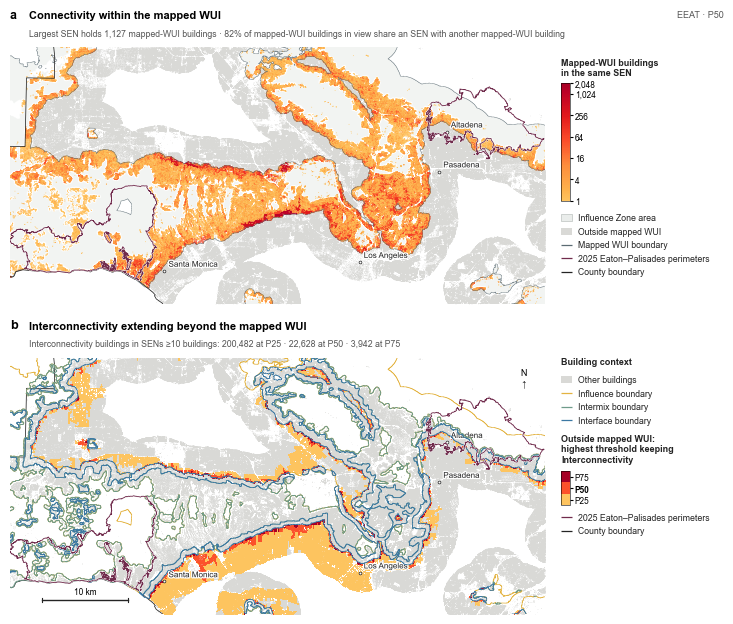

In [ ]:
WUI_FIGURE_EEAT = (
    FIGURES / 'fig5_santa_monica_wui_connectivity_persistence_eeat_p50'
)
fig_wui_paper_eeat, wui_paper_eeat = carsen_viz.plot_wui_connectivity_figure(
    EEAT_MAP_CACHE, EEAT_CENTROIDS, threshold_persistence_map, 'eeat',
    regional_eeat['wui'], la_county_boundary, WUI_FIGURE_BOUNDS,
    WUI_FIGURE_EEAT,
    probabilities=THRESHOLD_PROBABILITIES,
    method_label='EEAT · P50',
    fire_perimeters=WUI_FIGURE_FIRE_PERIMETERS,
    places=COUNTY_PLACES, size_scale_max=WUI_FIGURE_SIZE_SCALE_MAX,
)
wui_paper_eeat.to_csv(
    RESULTS / 'fig5_wui_connectivity_persistence_eeat_p50_summary.csv',
    index=False,
)
print('saved', WUI_FIGURE_EEAT.with_suffix('.png'))
display(wui_paper_eeat.T)
